<a href="https://colab.research.google.com/github/asm59-345/CryptoDATASET/blob/main/CryptoDATASET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
print(" Loading datasets...")
try:
    # Google Colab par files upload karne ke baad ye names match hone chahiye
    fg_df = pd.read_csv('fear_greed_index.csv')
    hist_df = pd.read_csv('historical_data.csv')
    print(" Files loaded successfully!")
except FileNotFoundError:
    print(" Error: Please upload 'fear_greed_index.csv' and 'historical_data.csv' to your Colab sidebar first.")

 Loading datasets...
 Files loaded successfully!


In [23]:
print("\n Cleaning and preprocessing data...")

# Parse Timestamp IST from historical data and extract only Date (YYYY-MM-DD)
hist_df['parsed_date'] = pd.to_datetime(hist_df['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
hist_df['Date_Only'] = hist_df['parsed_date'].dt.strftime('%Y-%m-%d')

# Numeric conversion with fallback handling
hist_df['Closed PnL'] = pd.to_numeric(hist_df['Closed PnL'], errors='coerce').fillna(0)
hist_df['Size USD'] = pd.to_numeric(hist_df['Size USD'], errors='coerce').fillna(0)

# Ensure sentiment date matches the format
fg_df['date'] = pd.to_datetime(fg_df['date']).dt.strftime('%Y-%m-%d')

# Merge both datasets on the Date Key
merged_df = pd.merge(hist_df, fg_df, left_on='Date_Only', right_on='date', how='inner')
print(f" Merged Dataset Shape: {merged_df.shape} (Total {len(merged_df)} trades linked with sentiment)")



 Cleaning and preprocessing data...
 Merged Dataset Shape: (211218, 22) (Total 211218 trades linked with sentiment)


In [24]:
print("\n Calculating performance metrics...")

# Custom function to calculate safe win rate
def calculate_win_rate(df):
    winning = (df['Closed PnL'] > 0).sum()
    losing = (df['Closed PnL'] < 0).sum()
    total_decisive = winning + losing
    return (winning / total_decisive * 100) if total_decisive > 0 else 0

# Group by classification
summary = merged_df.groupby('classification').agg(
    Total_Trades=('Trade ID', 'count'),
    Total_PnL_USD=('Closed PnL', 'sum'),
    Avg_PnL_USD=('Closed PnL', 'mean'),
    Avg_Size_USD=('Size USD', 'mean')
).reset_index()

# Map Win Rate mapping manually for safety
win_rates = []
for sentiment in summary['classification']:
    sub_df = merged_df[merged_df['classification'] == sentiment]
    win_rates.append(calculate_win_rate(sub_df))
summary['Win_Rate_Percent'] = win_rates

# Sort by standard market sentiment sequence
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
summary['classification'] = pd.Categorical(summary['classification'], categories=sentiment_order, ordered=True)
summary = summary.sort_values('classification').reset_index(drop=True)

print("\n--- PERFORMANCE SUMMARY TABLE ---")
print(summary.to_string(index=False))


 Calculating performance metrics...

--- PERFORMANCE SUMMARY TABLE ---
classification  Total_Trades  Total_PnL_USD  Avg_PnL_USD  Avg_Size_USD  Win_Rate_Percent
  Extreme Fear         21400   7.391102e+05    34.537862   5349.731843         76.215645
          Fear         61837   3.357155e+06    54.290400   7816.109931         87.288647
       Neutral         37686   1.292921e+06    34.307718   4782.732661         82.388898
         Greed         50303   2.150129e+06    42.743559   5736.884375         76.890690
 Extreme Greed         39992   2.715171e+06    67.892861   3112.251565         89.167026


In [25]:
print("\n Analyzing Order Side Bias across sentiments...")
side_bias = pd.crosstab(merged_df['classification'], merged_df['Side'], normalize='index') * 100
side_bias = side_bias.reindex(sentiment_order)
print(side_bias)


 Analyzing Order Side Bias across sentiments...
Side                  BUY       SELL
classification                      
Extreme Fear    51.098131  48.901869
Fear            48.951275  51.048725
Neutral         50.334342  49.665658
Greed           48.855933  51.144067
Extreme Greed   44.858972  55.141028



 Generating charts...


/tmp/ipykernel_1956/3647718177.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1956/3647718177.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


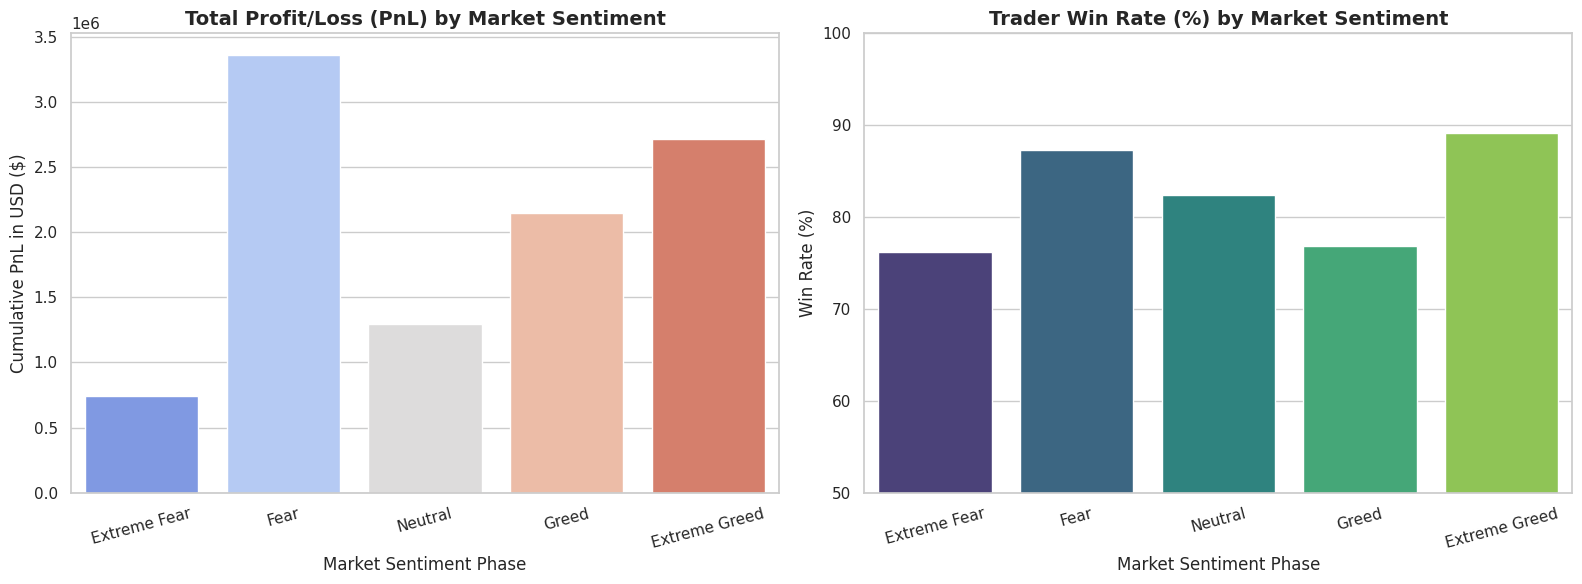

 Done! The metrics chart is saved as 'trader_performance_insights.png'. You can download it from the Colab files section.


In [28]:
print("\n Generating charts...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Plot 1: Total PnL Breakdown
sns.barplot(
    data=summary,
    x='classification',
    y='Total_PnL_USD',
    ax=axes[0],
    palette='coolwarm'
)
axes[0].set_title('Total Profit/Loss (PnL) by Market Sentiment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Market Sentiment Phase', fontsize=12)
axes[0].set_ylabel('Cumulative PnL in USD ($)', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)

# Plot 2: Win Rate Analysis
sns.barplot(
    data=summary,
    x='classification',
    y='Win_Rate_Percent',
    ax=axes[1],
    palette='viridis'
)
axes[1].set_title('Trader Win Rate (%) by Market Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Market Sentiment Phase', fontsize=12)
axes[1].set_ylabel('Win Rate (%)', fontsize=12)
axes[1].set_ylim(50, 100) # Highlight the top tier differences clearly
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('trader_performance_insights.png', dpi=300)
plt.show()
print(" Done! The metrics chart is saved as 'trader_performance_insights.png'. You can download it from the Colab files section.")


 Generating Advanced Analytics for Hiring Edge...

 Top 5 Coins by Volume in 'Extreme Fear':
Coin
HYPE    10278
SOL      1878
BTC      1765
@107     1519
ETH      1393
Name: count, dtype: int64

 Top 5 Coins by Volume in 'Extreme Greed':
Coin
@107    10403
HYPE     5683
BTC      2436
ETH      2024
SOL      1913
Name: count, dtype: int64

 Capital Efficiency (Avg PnL per Dollar Invested):
  classification  PnL_to_Size_Ratio
0   Extreme Fear           0.006456
1           Fear           0.006946
2        Neutral           0.007173
3          Greed           0.007451
4  Extreme Greed           0.021815


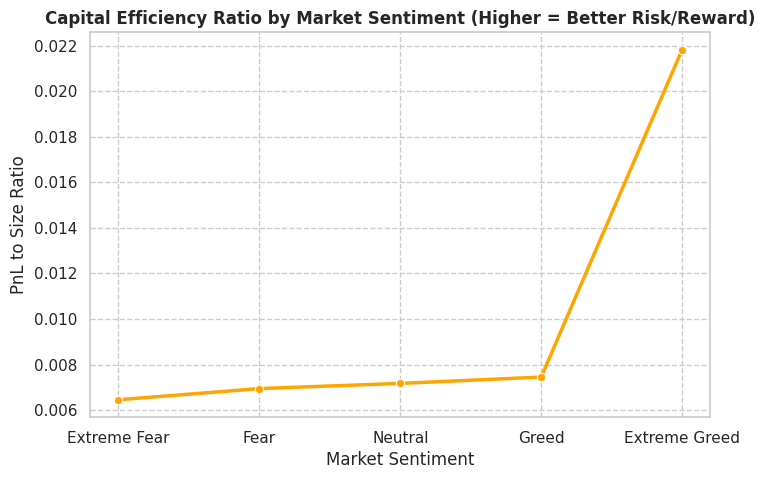

 Advanced insights chart saved as 'advanced_capital_efficiency.png'


In [29]:
print("\n Generating Advanced Analytics for Hiring Edge...")

# 1. Top 5 Coins Traded During Extreme Fear vs Extreme Greed
print("\n Top 5 Coins by Volume in 'Extreme Fear':")
fear_coins = merged_df[merged_df['classification'] == 'Extreme Fear']['Coin'].value_counts().head(5)
print(fear_coins)

print("\n Top 5 Coins by Volume in 'Extreme Greed':")
greed_coins = merged_df[merged_df['classification'] == 'Extreme Greed']['Coin'].value_counts().head(5)
print(greed_coins)

# 2. Avg Profit Per Trade vs Risk Size Ratio
summary['PnL_to_Size_Ratio'] = summary['Avg_PnL_USD'] / summary['Avg_Size_USD']
print("\n Capital Efficiency (Avg PnL per Dollar Invested):")
print(summary[['classification', 'PnL_to_Size_Ratio']])

# 3. Chart: Capital Efficiency across Sentiments
plt.figure(figsize=(8, 5))
sns.lineplot(data=summary, x='classification', y='PnL_to_Size_Ratio', marker='o', linewidth=2.5, color='orange')
plt.title('Capital Efficiency Ratio by Market Sentiment (Higher = Better Risk/Reward)', fontsize=12, fontweight='bold')
plt.ylabel('PnL to Size Ratio')
plt.xlabel('Market Sentiment')
plt.grid(True, linestyle='--')
plt.savefig('advanced_capital_efficiency.png', dpi=300)
plt.show()
print(" Advanced insights chart saved as 'advanced_capital_efficiency.png'")